The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


2x2 Grid Plot saved successfully to spatial_distribution_2x2.png


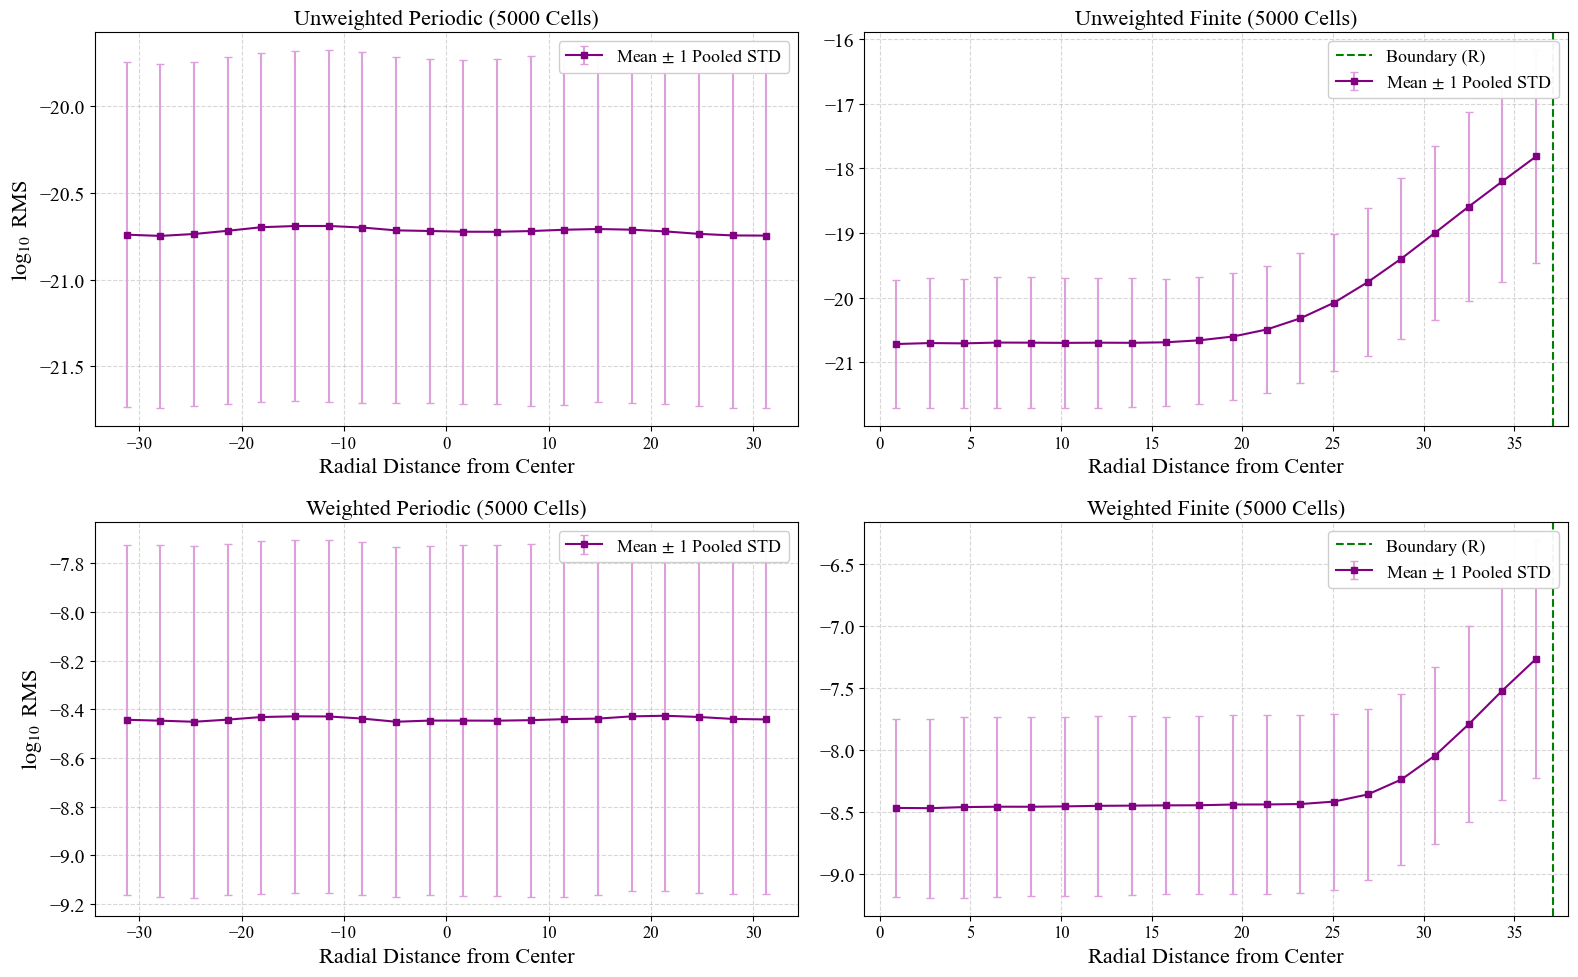

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1) Setup & Publication styling
# ==========================================
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif', 'serif'],
    'mathtext.fontset': 'stix', 
    'font.size': 14,
    'axes.labelsize': 16,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 14,
    'legend.fontsize': 13,
    'figure.titlesize': 18
})

num_cells_target = 5000

# Calculate R_float for the boundary line
area_per_cell = np.sqrt(3) / 2.0
total_area = num_cells_target * area_per_cell
R_float = np.sqrt(total_area / np.pi)

# Define the folders and their corresponding readable titles
folders = [
    "a_unweighted_periodic",
    "b_unweighted_finite",
    "c_weighted_periodic",
    "d_weighted_finite"
]

titles = [
    "Unweighted Periodic",
    "Unweighted Finite",
    "Weighted Periodic",
    "Weighted Finite"
]

# ==========================================
# 2) Figure Setup (2x2 Grid)
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, (folder, title) in enumerate(zip(folders, titles)):
    ax = axes[i]
    
    # Handle possible subfolder naming conventions
    path_primary = os.path.join(folder, f"cell_data_{num_cells_target}")
    path_fallback = os.path.join(folder, str(num_cells_target))
    
    base_path = path_primary if os.path.exists(path_primary) else path_fallback
    space_file = os.path.join(base_path, 'log_rms_vs_space.npy')
    
    if os.path.exists(space_file):
        # Load Data
        loaded_space_data = np.load(space_file)
        plot_bin_centers = loaded_space_data[0]
        plot_spatial_mean = loaded_space_data[1]
        plot_spatial_std = loaded_space_data[2]
        
        # Plot Error Bars
        ax.errorbar(plot_bin_centers, plot_spatial_mean, yerr=plot_spatial_std, fmt='-s', markersize=4, 
                    color='purple', ecolor='plum', capsize=3, elinewidth=1.5, label=r'Mean $\pm$ 1 Pooled STD')
        
        # Plot Boundary (R) only for Finite cases, as Periodic doesn't have a circular boundary
        if "finite" in folder:
            ax.axvline(R_float, color='green', linestyle='--', label='Boundary (R)')
            
        # Formatting
        ax.set_title(f"{title} ({num_cells_target} Cells)")
        ax.set_xlabel("Radial Distance from Center")
        
        # Only set the y-axis label for the left-most plots in the grid
        if i % 2 == 0:
            ax.set_ylabel(r"$\log_{10}$ RMS")
        
        ax.legend(loc='upper right', framealpha=0.95)
        ax.grid(True, which="both", ls="--", alpha=0.5)
        
    else:
        # Fallback if data is missing
        ax.text(0.5, 0.5, f"Data not found:\n{space_file}", 
                ha='center', va='center', transform=ax.transAxes, fontsize=14, color='red')
        ax.set_title(f"{title} (Missing)")
        ax.set_xticks([])
        ax.set_yticks([])

# ==========================================
# 3) Final Cleanup and Export
# ==========================================
plt.tight_layout()

out_png = 'spatial_distribution_2x2.png'
out_eps = 'spatial_distribution_2x2.eps'

plt.savefig(out_png, dpi=300, bbox_inches='tight')
plt.savefig(out_eps, format='eps', bbox_inches='tight')

print(f"2x2 Grid Plot saved successfully to {out_png}")
plt.show()